# Sangamon River Basin Visualization and Geometric Analysis

This notebook performs the following tasks:
1. Loads USGS basin data and National Hydrography Dataset (NHD) data for the Sangamon River basin.
2. Visualizes selected USGS gauge catchments, the river network, and hillslopes on a map.
3. Performs exploratory geometric analysis on selected basin polygons (containment, symmetric difference).

In [1]:
# %pip install geopandas matplotlib cartopy

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path # Used for path operations, though specific paths are commented out now
from matplotlib.patches import Patch
from cartopy.crs import PlateCarree
from cartopy.feature import BORDERS, COASTLINE, STATES

In [2]:
#HOME = Path().home()
#HPCHOME = HOME / "hpchome"
#LSS = HOME / "LSS"
#NICOLAS = LSS / "lss_nicolas"

# Define the map projection used throughout
plate_carre = PlateCarree()

## 1. Data Loading for Visualization

 Here, we load the necessary datasets for creating the map visualization:
 - A GeoJSON file containing USGS basin polygons for the entire US.
 - Specific NHD data (Catchment boundaries and Flowlines) for a particular region (presumably related to gauge '05583000').

 We then filter the USGS basins to select specific gauges within the Sangamon River basin area.


In [3]:
# --- Load USGS Basins ---
usgs_basins_file = "usgs-basins.geojson"
print(f"Loading USGS basins from: {usgs_basins_file}")
usgs_gdf = gpd.read_file(usgs_basins_file) # Contains gauge catchment polygons for the US

# Ensure the coordinate reference system (CRS) is EPSG:4326 (WGS 84)
if usgs_gdf.crs != "EPSG:4326":
    print(f"Original CRS: {usgs_gdf.crs}. Converting to EPSG:4326.")
    usgs_gdf = usgs_gdf.to_crs(epsg=4326)
else:
    print(f"USGS Basins CRS is already EPSG:4326.")

# --- Define Target Sangamon Gauges ---
# List of USGS gauge IDs within the Sangamon basin to focus on

# np.loadtxt(NICOLAS / "DA/Zhihua/hlm_data/hlm_data/gauges_w_data.txt")
sangamon_gauges = [
    # "05578100",
    # "05578000",
    # "05579630",
    # "05576500",
    # "05580950",
    # "05577500",
    # "05576250",
    # "05576000",
    # "05580000",
    # "05582000",
    # "05576193",
    # "05583000",
    # "05570910",
    # "05578250",
    # "05576090",
    # "05573540",
    # "05578500",
    # "05579725",
    # "05579500",
    # "05572000",
#     
#     p1 = '05580950'
# p2 = '05579725'

    '05583000', # Largest catchment in this list, used for NHD data file names
    # '05578000',
    # '05576500',
    # '05582000',
    # '05573540',
    # '05576000',
    # '05572000',
    # '05578500',
    # '05576250',
    # '05570910',
    # '05580000',
    # '05579500',
    # '05577500',
    '05580950', # Point p1 used later for geometric analysis
    '05579725', # Point p2 used later for geometric analysis
    # '05579630',
]
print(f"Target Sangamon gauge IDs: {sangamon_gauges}")

Loading USGS basins from: usgs-basins.geojson
Original CRS: EPSG:4269. Converting to EPSG:4326.
Target Sangamon gauge IDs: ['05583000', '05580950', '05579725']


In [4]:
# --- Filter Basins for Visualization ---
# Create a subset GeoDataFrame containing only the selected Sangamon gauges
# Sort by area (descending) for potentially better plotting order or analysis
# Catchmnet at each gauge for the sangamon
usgs_subset_viz = usgs_gdf[usgs_gdf['usgs_id'].isin(sangamon_gauges)].sort_values(by='area', ascending=False)
# usgs_subset.to_file("05583000.geojson", driver='GeoJSON')
print(f"Selected {len(usgs_subset_viz)} gauges for visualization.")
print("Selected gauge IDs (sorted by area desc):", usgs_subset_viz.usgs_id.values) # Optional print

# --- Load NHD Data ---
# Load National Hydrography Dataset components for the area around gauge 05583000
catchment_file = "Catchment-05583000.gpkg" # Hillslopes / local drainage areas
flowline_file = "NHDFlowline-05583000.gpkg" # River network lines
print(f"Loading NHD Catchments from: {catchment_file}")
catchment_nhd = gpd.read_file(catchment_file)
print(f"Loading NHD Flowlines from: {flowline_file}")
flowline_nhd = gpd.read_file(flowline_file)
# area = gpd.read_file("NHDArea-05583000.gpkg")
# line = gpd.read_file("NHDLine-05583000.gpkg")
# waterbody = gpd.read_file("NHDWaterbody-05583000.gpkg")

# Optional: Ensure NHD data CRS matches if necessary (often projected, convert to 4326 for plotting with base map)
if catchment_nhd.crs != "EPSG:4326":
    print(f"Converting NHD Catchment CRS from {catchment_nhd.crs} to EPSG:4326.")
    catchment_nhd = catchment_nhd.to_crs(epsg=4326)
if flowline_nhd.crs != "EPSG:4326":
    print(f"Converting NHD Flowline CRS from {flowline_nhd.crs} to EPSG:4326.")
    flowline_nhd = flowline_nhd.to_crs(epsg=4326)

Selected 3 gauges for visualization.
Selected gauge IDs (sorted by area desc): ['05583000' '05580950' '05579725']
Loading NHD Catchments from: Catchment-05583000.gpkg
Loading NHD Flowlines from: NHDFlowline-05583000.gpkg
Converting NHD Catchment CRS from EPSG:4269 to EPSG:4326.
Converting NHD Flowline CRS from EPSG:4269 to EPSG:4326.


/home/zli333/virtenvs/Hydro_cuda/lib/python3.11/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_read(


## 2. Map Visualization

 This section creates a map showing the geographic context. It plots:
 - Basemap features (coastlines, country borders, US state borders).
 - The selected USGS gauge catchment polygons (`usgs_subset_viz`), colored by gauge ID.
 - The NHD river network (`flowline_nhd`).
 - The NHD catchment boundaries (`catchment_nhd`).
 - Specific points of interest (e.g., locations related to gauges '05579725' and '05580950').
 - Gridlines and sets appropriate map bounds.

## Hydrological Terms: Catchment, Flowline, Hillslope, and Gauge

These terms describe components of a river system and the landscape that contributes water to it, often with hierarchical relationships:

1.  **Catchment (also Watershed or Basin):**
    * This represents the **total land surface area** from which water flows downhill towards a single, common outlet point (often defined by a gauge location or the confluence with a larger river).
    * It acts as a container: a catchment encompasses the entire river network (`Flowlines`) and all the contributing land (`Hillslopes`) within its boundaries.
    * **Hierarchy:** Catchments are hierarchical. The catchment defined by a downstream point naturally *contains* the entire catchments of all points located upstream within its river network.

2.  **Flowline:**
    * This is a **line feature** representing the path of a river, stream, or other water channel within the drainage network.
    * Flowlines form the network that collects and transports water through the catchment. They exist *within* a catchment.
    * They receive water from adjacent `Hillslopes`.

3.  **Hillslope:**
    * This refers to a **smaller land area** that drains *directly* into a specific segment of a `Flowline`. It represents the local contributing area for overland flow before water reaches a defined channel.
    * Hillslopes are the fundamental land units that, when aggregated, make up the entire `Catchment` area. They are *contained within* a catchment and drain *towards* a flowline.

4.  **Gauge:**
    * This is a specific **point location**, typically situated *on* a `Flowline` (river or stream).
    * At this point, hydrological measurements (like water level, flow rate/discharge) are taken.
    * A gauge is often used to define the outlet point for a specific `Catchment` of interest. The catchment associated with a gauge represents all the land area upstream that contributes water flow *to that gauge location*.

In [ ]:
# gdf = gpd.read_file("sangamon-remove-holes_0.gpkg")

# if gdf.crs != "EPSG:4326":
#     gdf = gdf.to_crs(epsg=4326)

Plotting 3 USGS catchments.
Plotting NHD flowlines.
Plotting NHD catchment boundaries.
Plotting specific point locations.
Setting map extent to Lon: [-89.15, -88.75], Lat: [40.25, 40.65]


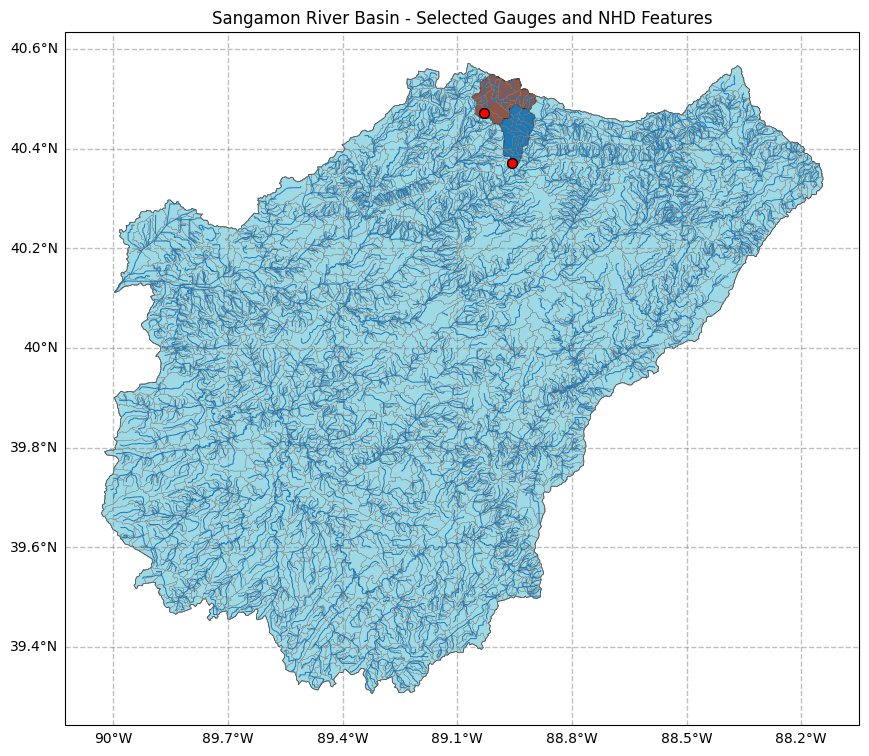

In [7]:
# --- Create Map Plot ---
fig, ax = plt.subplots(figsize=(12, 9), subplot_kw={'projection': plate_carre})

# Add background map features
ax.add_feature(COASTLINE, zorder=1)
ax.add_feature(BORDERS, zorder=1)
ax.add_feature(STATES, zorder=1)

# Plot USGS gauge catchments (selected subset)
# Uses 'tab20' colormap for distinct colors, black edges for definition
usgs_subset_viz.plot(ax=ax, column='usgs_id', cmap='tab20', legend=False, edgecolor='black', linewidth=0.5, zorder=2)
print(f"Plotting {len(usgs_subset_viz)} USGS catchments.")

# Plot NHD river network
# Thin blue lines ('C0' is often blue in matplotlib default cycle)
flowline_nhd.plot(ax=ax, lw=0.7, color="C0", zorder=3) # Changed to C0 for blue
print("Plotting NHD flowlines.")

# Plot NHD catchment boundaries (hillslopes)
# Plotted with no facecolor (transparent fill) and thin lines
catchment_nhd.plot(ax=ax, facecolor="none", lw=0.2, edgecolor='gray', zorder=2) # Changed to gray edgecolor
print("Plotting NHD catchment boundaries.")

# Add gridlines with labels
gl = ax.gridlines(draw_labels=True, crs=plate_carre, linewidth=1, color='gray', alpha=0.5, linestyle='--', zorder=4)
gl.top_labels = False # Disable labels on top
gl.right_labels = False # Disable labels on right

# Define and plot specific points of interest
# Coordinates likely correspond to gauges '05579725' and '05580950'
# 5579725	-9999	13551669	40.371162	-88.956642
# 5580950	-9999	13552723	40.471527	-89.030457
lons = [-88.956642, -89.030457]
lats = [40.371162, 40.471527]
ax.scatter(lons, lats, transform=plate_carre, zorder=5, color="red", s=50, edgecolor='black', label='Specific Locations') # Made points more visible
print("Plotting specific point locations.")

# Set map extent (longitude and latitude limits)
# Adjusted slightly for better framing based on previous plot
# lon_min, lon_max = -89.15, -88.75
# lat_min, lat_max = 40.25, 40.65
# ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=plate_carre)
print(f"Setting map extent to Lon: [{lon_min}, {lon_max}], Lat: [{lat_min}, {lat_max}]")

# Add title and legend (optional, for the scatter points)
ax.set_title("Sangamon River Basin - Selected Gauges and NHD Features")
# ax.legend() # Uncomment if you want a legend for the scatter points

plt.show()


In [34]:
# LSS/lss_nicolas/DA/Zhihua/hlm_data/hlm_data/sangamon.gzip

## 3. Geometric Analysis

 This section focuses on exploring the spatial relationships between different gauge catchment polygons using `geopandas` geometric operations.

 **Note:** It appears the original notebook loaded a *different* GeoJSON file (`05583000.geojson`) specifically for this analysis section. We will replicate that here for consistency, loading it into a separate variable `usgs_subset_analysis`. If this file actually contains the same data as filtered earlier, you could simplify by reusing `usgs_subset_viz`.


In [6]:
# --- Load Data for Geometric Analysis ---
analysis_geojson_file = "05583000.geojson"
try:
    print(f"Loading data for analysis from: {analysis_geojson_file}")
    # Assuming this file contains the geometries for the gauges listed in `sangamon_gagues` or a relevant subset
    usgs_subset_analysis = gpd.read_file(analysis_geojson_file)
    # Ensure CRS is correct
    if usgs_subset_analysis.crs != "EPSG:4326":
         usgs_subset_analysis = usgs_subset_analysis.to_crs(epsg=4326)
    print(f"Loaded {len(usgs_subset_analysis)} features for analysis.")
except Exception as e:
    print(f"Error loading {analysis_geojson_file}: {e}")
    print("Skipping geometric analysis section.")
    # Assign an empty GeoDataFrame or None to avoid errors later if needed
    usgs_subset_analysis = None

# --- Perform Analysis (only if data loaded successfully) ---
if usgs_subset_analysis is not None and not usgs_subset_analysis.empty:
    # Example 1: Containment Check
    # Check if the catchment for gauge '05579725' contains the catchment for '05582000'
    try:
        geom_05579725 = usgs_subset_analysis[usgs_subset_analysis.usgs_id == '05579725'].geometry.iloc[0]
        geom_05582000 = usgs_subset_analysis[usgs_subset_analysis.usgs_id == '05582000'].geometry.iloc[0]
        contains_check = geom_05579725.contains(geom_05582000)
        print(f"\nAnalysis: Does catchment '05579725' contain '05582000'? {contains_check}")
    except IndexError:
        print("Warning: Could not find one or both gauges ('05579725', '05582000') in the analysis data.")

    # Example 2: Symmetric Difference
    # Find the areas that are in one catchment but not the other (useful for nested catchments)
    try:
        geom_05583000 = usgs_subset_analysis[usgs_subset_analysis.usgs_id == '05583000'].geometry.iloc[0]
        geom_05578000 = usgs_subset_analysis[usgs_subset_analysis.usgs_id == '05578000'].geometry.iloc[0]

        # Check containment first (often upstream is contained within downstream)
        contains_check_1 = geom_05583000.contains(geom_05578000)
        contains_check_2 = geom_05578000.contains(geom_05583000)
        print(f"Analysis: Does '05583000' contain '05578000'? {contains_check_1}")
        print(f"Analysis: Does '05578000' contain '05583000'? {contains_check_2}")

        # Calculate the symmetric difference (area unique to either polygon)
        sym_diff_geom = geom_05583000.symmetric_difference(geom_05578000)
        print(f"Analysis: Symmetric difference area between '05583000' and '05578000': {sym_diff_geom.area:.6f} (in CRS units, likely degrees^2)")

        # Verify area relationship for nested catchments (if one contains the other)
        # Area(Larger) should approx equal Area(Smaller) + Area(Symmetric Difference)
        if contains_check_1: # If 05583000 contains 05578000
             summed_area = geom_05578000.area + sym_diff_geom.area
             print(f"  Area('05578000') + Area(SymDiff) = {summed_area:.6f}")
             print(f"  Area('05583000')                   = {geom_05583000.area:.6f}")
             print(f"  Areas match? {np.isclose(geom_05583000.area, summed_area)}")

    except IndexError:
        print("Warning: Could not find one or both gauges ('05583000', '05578000') in the analysis data.")


    # Example 3: Disjoint Check (using area relationship from symmetric difference)
    # Check if two catchments are likely disjoint (non-overlapping)
    try:
        p1_id = '05580950'
        p2_id = '05579725'
        geom_p1 = usgs_subset_analysis[usgs_subset_analysis.usgs_id == p1_id].geometry.iloc[0]
        geom_p2 = usgs_subset_analysis[usgs_subset_analysis.usgs_id == p2_id].geometry.iloc[0]
        sym_diff_p1p2 = geom_p1.symmetric_difference(geom_p2)

        print(f"\nAnalysis: Checking relationship between '{p1_id}' and '{p2_id}':")
        print(f"  Area('{p1_id}') = {geom_p1.area:.6f}")
        print(f"  Area('{p2_id}') = {geom_p2.area:.6f}")
        print(f"  Area(SymDiff) = {sym_diff_p1p2.area:.6f}")
        print(f"  Area('{p1_id}') + Area('{p2_id}') = {(geom_p1.area + geom_p2.area):.6f}")

        # If Area(SymDiff) is approximately equal to Area(P1) + Area(P2), they are likely disjoint
        is_disjoint_approx = np.isclose(sym_diff_p1p2.area, geom_p1.area + geom_p2.area)
        print(f"  Area(SymDiff) ≈ Area(P1) + Area(P2)? {is_disjoint_approx} => Likely disjoint? {is_disjoint_approx}")

        # A more direct check for disjointness
        is_disjoint_direct = geom_p1.disjoint(geom_p2)
        print(f"  Direct disjoint check: {is_disjoint_direct}")

    except IndexError:
        print(f"Warning: Could not find one or both gauges ('{p1_id}', '{p2_id}') in the analysis data.")

else:
    print("\nSkipping geometric analysis because analysis data was not loaded.")


Loading data for analysis from: 05583000.geojson
Loaded 16 features for analysis.

Analysis: Does catchment '05579725' contain '05582000'? False
Analysis: Does '05583000' contain '05578000'? False
Analysis: Does '05578000' contain '05583000'? False
Analysis: Symmetric difference area between '05583000' and '05578000': 0.556724 (in CRS units, likely degrees^2)

Analysis: Checking relationship between '05580950' and '05579725':
  Area('05580950') = 0.009756
  Area('05579725') = 0.006889
  Area(SymDiff) = 0.016639
  Area('05580950') + Area('05579725') = 0.016645
  Area(SymDiff) ≈ Area(P1) + Area(P2)? False => Likely disjoint? False
  Direct disjoint check: False


In [37]:
usgs_subset = gpd.read_file("05583000.geojson") # gauges for the US


In [38]:
g05582000 = usgs_subset[usgs_subset.usgs_id == '05582000'].geometry.values[0]
g05579725 = usgs_subset[usgs_subset.usgs_id == '05579725'].geometry.values[0]

In [39]:
g05579725.contains(g05582000)

False

In [40]:
g05583000 = usgs_subset[usgs_subset.usgs_id == '05583000'].geometry.values[0]
g05578000 = usgs_subset[usgs_subset.usgs_id == '05578000'].geometry.values[0]
g05583000.contains(g05578000), g05578000.contains(g05583000)

(False, False)

In [41]:
a = usgs_subset[usgs_subset.usgs_id == '05578000'].geometry.values[0]
b = usgs_subset[usgs_subset.usgs_id == '05583000'].geometry.values[0]

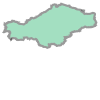

In [42]:
a.symmetric_difference(b)

In [43]:
c = b.symmetric_difference(a)

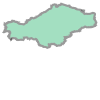

In [44]:
c


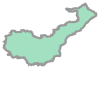

In [45]:
a

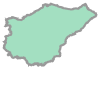

In [46]:
a.union(c)

In [47]:
c.area + a.area

1.3909583894517301

In [48]:
b.area

1.3909306642999992

In [49]:
p1 = '05580950'
p2 = '05579725'
a = usgs_subset[usgs_subset.usgs_id == p1].geometry.values[0]
b = usgs_subset[usgs_subset.usgs_id == p2].geometry.values[0]
c = b.symmetric_difference(a)

In [50]:
a.area, b.area, c.area

(0.009756453349999816, 0.00688891640000013, 0.016638896539419874)

In [51]:
a.area + b.area 
# c.area \approx a.area + b.area  => disjoint 

0.016645369749999944